Error: Missing column: Transaction_ID

===== LIBRARY STATISTICS =====
Most Borrowed Book: The Devil in the White City
Average Duration: 16.66
Standard Deviation: 7.9
Busiest Day: 28-05-2025

===== REPORT =====
       Transaction ID        Date User ID                   Book Title  \
count             350         350     350                          350   
unique            350         315      99                          134   
top           TXN0001  28-05-2025  USR024  The Devil in the White City   
freq                1           3       8                            7   
mean              NaN         NaN     NaN                          NaN   
std               NaN         NaN     NaN                          NaN   
min               NaN         NaN     NaN                          NaN   
25%               NaN         NaN     NaN                          NaN   
50%               NaN         NaN     NaN                          NaN   
75%               NaN         NaN     NaN         

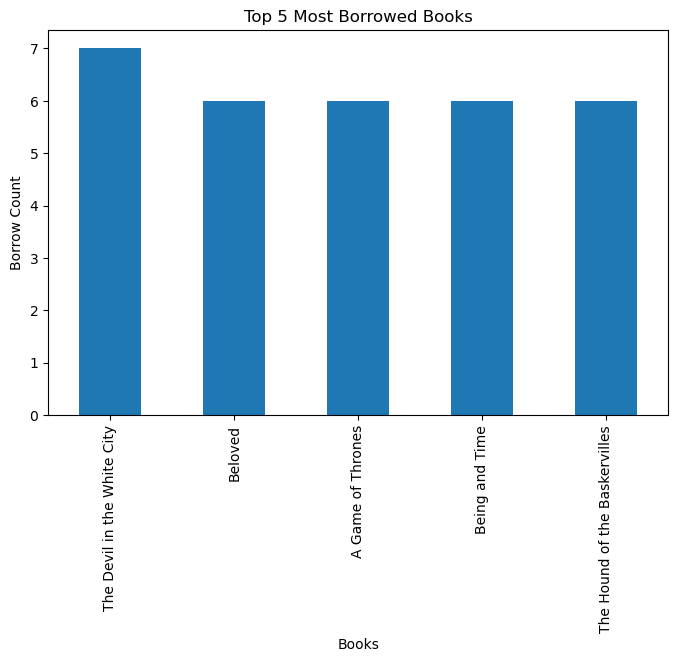

C:\Users\Admin\AppData\Local\Temp\ipykernel_5016\3397277804.py:116: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  self.data['Date'] = pd.to_datetime(


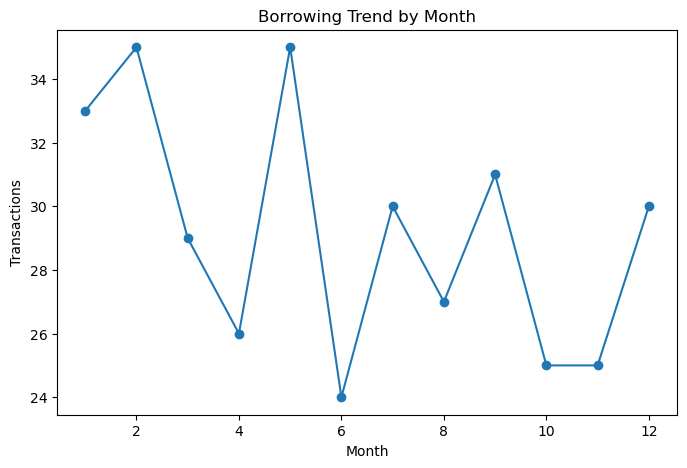

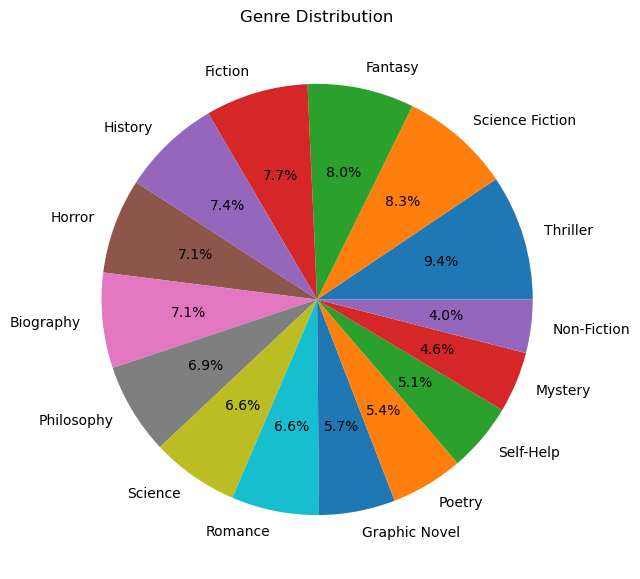

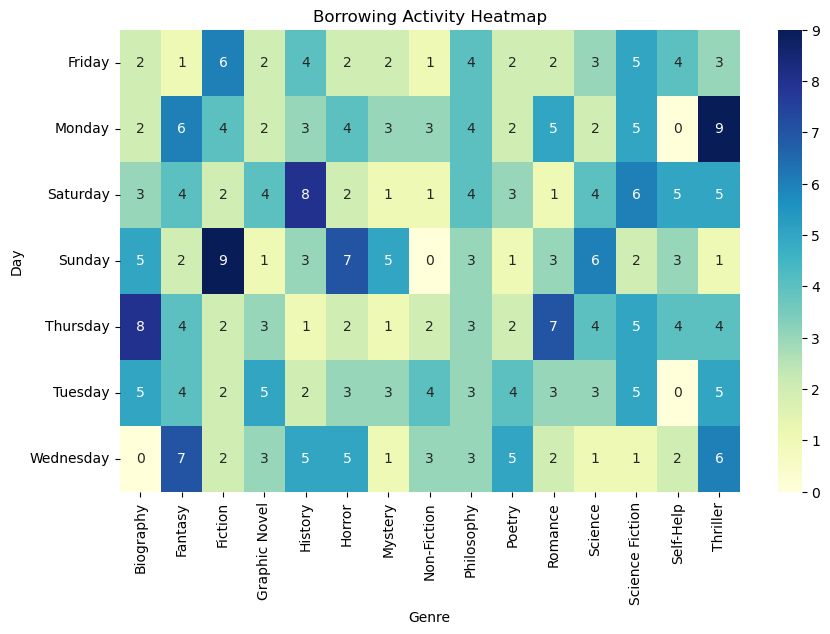

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


class LibraryDashboard:

    def __init__(self):
        self.data = None

    def load_data(self, file_path):
        try:
            self.data = pd.read_csv(r"C:\Users\Admin\Desktop\library_transactions.csv")

            required_columns = [
                'Transaction_ID',
                'Date',
                'User_ID',
                'Book Title',
                'Genre',
                'Borrowing Duration (Days)'
            ]

            for col in required_columns:
                if col not in self.data.columns:
                    raise ValueError(f"Missing column: {col}")

            print("Dataset loaded successfully!")

            self.validate_data()

        except Exception as e:
            print("Error:", e)

    def validate_data(self):

        print("\nChecking missing values...")

        missing = self.data.isnull().sum()

        print(missing)

        self.data.dropna(inplace=True)

        duplicates = self.data.duplicated().sum()

        print(f"Duplicate records: {duplicates}")

        self.data.drop_duplicates(inplace=True)

    def calculate_statistics(self):

        print("\n===== LIBRARY STATISTICS =====")

        most_borrowed = self.data['Book Title'].value_counts().idxmax()

        avg_duration = np.mean(
            self.data['Borrowing Duration (Days)']
        )

        std_duration = np.std(
            self.data['Borrowing Duration (Days)']
        )

        busiest_day = (
            self.data['Date']
            .value_counts()
            .idxmax()
        )

        print("Most Borrowed Book:", most_borrowed)
        print("Average Duration:", round(avg_duration, 2))
        print("Standard Deviation:", round(std_duration, 2))
        print("Busiest Day:", busiest_day)

    def filter_transactions(self, genre=None):

        if genre:
            filtered = self.data[self.data['Genre'] == genre]

            print(filtered)

            return filtered

        return self.data

    def generate_report(self):

        print("\n===== REPORT =====")

        print(self.data.describe(include='all'))

    def top_books_chart(self):

        top_books = (
            self.data['Book Title']
            .value_counts()
            .head(5)
        )

        plt.figure(figsize=(8, 5))

        top_books.plot(kind='bar')

        plt.title("Top 5 Most Borrowed Books")

        plt.xlabel("Books")

        plt.ylabel("Borrow Count")

        plt.show()

    def monthly_trend_chart(self):

        self.data['Date'] = pd.to_datetime(
            self.data['Date']
        )

        monthly = (
            self.data
            .groupby(self.data['Date'].dt.month)
            .size()
        )

        plt.figure(figsize=(8, 5))

        monthly.plot(marker='o')

        plt.title("Borrowing Trend by Month")

        plt.xlabel("Month")

        plt.ylabel("Transactions")

        plt.show()

    def genre_pie_chart(self):

        genre_counts = self.data['Genre'].value_counts()

        plt.figure(figsize=(7, 7))

        plt.pie(
            genre_counts,
            labels=genre_counts.index,
            autopct='%1.1f%%'
        )

        plt.title("Genre Distribution")

        plt.show()

    def activity_heatmap(self):

        self.data['Date'] = pd.to_datetime(
            self.data['Date']
        )

        self.data['Day'] = (
            self.data['Date']
            .dt.day_name()
        )

        heat_data = pd.crosstab(
            self.data['Day'],
            self.data['Genre']
        )

        plt.figure(figsize=(10, 6))

        sns.heatmap(
            heat_data,
            annot=True,
            cmap='YlGnBu'
        )

        plt.title("Borrowing Activity Heatmap")

        plt.show()


def main():

    dashboard = LibraryDashboard()

    dashboard.load_data(
        "library_transactions.csv"
    )

    dashboard.calculate_statistics()

    dashboard.generate_report()

    dashboard.filter_transactions("Fiction")

    dashboard.top_books_chart()

    dashboard.monthly_trend_chart()

    dashboard.genre_pie_chart()

    dashboard.activity_heatmap()


if __name__ == "__main__":
    main()